In [1]:
#data loading
import os
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime

BASE_DIR = Path(r"C:\Users\adrme\OneDrive\Music\Project\Data")
CLEANED_DATA1_FOLDER = BASE_DIR / 'Cleaned_Data1'
CLEANED_DATA2_FOLDER = BASE_DIR / 'Cleaned_Data2'
EXPECTED_STATE_COUNT = 37 

def parse_date(filename):
    try:
        date_part = filename.split('_')[0]
        return datetime.strptime(date_part, '%d.%m.%y')
    except:
        return None

def load_data_strict_37():
    c1_files = list(CLEANED_DATA1_FOLDER.rglob('*.xlsx')) + list(CLEANED_DATA1_FOLDER.rglob('*.xls'))
    c2_files = list(CLEANED_DATA2_FOLDER.rglob('*.xlsx')) + list(CLEANED_DATA2_FOLDER.rglob('*.xls'))

    c1_map = {parse_date(f.name): f for f in c1_files if parse_date(f.name)}
    c2_map = {parse_date(f.name): f for f in c2_files if parse_date(f.name)}
    common_dates = sorted(list(set(c1_map.keys()) & set(c2_map.keys())))
    print(f"Aligned {len(common_dates)} matching dates.")

    national_list = []
    state_list = []
    
    STANDARD_STATE_LIST = None
    C2_FEATURES = ['Day Demand (MU)', 'Percentage Met', 'Load Factor']
    rejected_count = 0

    for dt in common_dates:
        try:
            df_c2 = pd.read_excel(c2_map[dt], header=0)
            if 'States' not in df_c2.columns: continue
            df_c2 = df_c2[df_c2['States'].astype(str).str.lower() != 'total']

            if len(df_c2) != EXPECTED_STATE_COUNT:
                rejected_count += 1
                continue

            df_c2.sort_values('States', inplace=True)
            current_states = df_c2['States'].values
            if STANDARD_STATE_LIST is None:
                STANDARD_STATE_LIST = current_states
            elif not np.array_equal(current_states, STANDARD_STATE_LIST):
                rejected_count += 1
                continue

            if not all(col in df_c2.columns for col in C2_FEATURES): continue
            state_mat = df_c2[C2_FEATURES].values.astype(float)

            df_c1 = pd.read_excel(c1_map[dt], header=0)
            if 'Total' not in df_c1.columns: continue
            national_vec = df_c1['Total'].values.astype(float)
            national_list.append(national_vec)
            state_list.append(state_mat)

        except Exception as e:
            print(f"Error reading {dt}: {e}")
            continue

    if not national_list:
        print("Error: No valid files found with 37 states.")
        return None, None

    X_national = np.array(national_list)
    X_states = np.array(state_list)

    print("\n--- Data Loading Complete ---")
    print(f"Files Rejected (Wrong Count): {rejected_count}")
    print(f"Files Loaded Successfully:    {X_national.shape[0]}")
    print(f"National Data Shape (2D):     {X_national.shape}")
    print(f"State Data Shape    (3D):     {X_states.shape}")
    
    return X_national, X_states

X_national, X_states = load_data_strict_37()

Aligned 928 matching dates.

--- Data Loading Complete ---
Files Rejected (Wrong Count): 348
Files Loaded Successfully:    578
National Data Shape (2D):     (578, 5)
State Data Shape    (3D):     (578, 37, 3)


In [2]:
#data preprocessing
import numpy as np
from sklearn.preprocessing import MinMaxScaler

WINDOW_SIZE = 90
FORECAST_HORIZON = 90
TRAIN_SPLIT = 0.8

def data_preprocessing(X_nat_raw, X_st_raw):
    split_idx = int(len(X_nat_raw) * TRAIN_SPLIT)

    scaler_nat = MinMaxScaler(feature_range=(0, 1))
    scaler_st = MinMaxScaler(feature_range=(0, 1))
    
    scaler_nat.fit(X_nat_raw[:split_idx])
    
    num_states = X_st_raw.shape[1]
    num_features = X_st_raw.shape[2]
    X_st_train_flat = X_st_raw[:split_idx].reshape(-1, num_features)
    scaler_st.fit(X_st_train_flat)
    
    X_nat_scaled = scaler_nat.transform(X_nat_raw)
    X_st_flat = X_st_raw.reshape(-1, num_features)
    X_st_scaled = scaler_st.transform(X_st_flat).reshape(X_st_raw.shape)
    
    X_nat_seq, X_st_seq, y_st_seq = [], [], []
    
    max_idx = len(X_nat_scaled) - WINDOW_SIZE - FORECAST_HORIZON
    
    for i in range(max_idx):
        X_nat_seq.append(X_nat_scaled[i : i + WINDOW_SIZE])
        X_st_seq.append(X_st_scaled[i : i + WINDOW_SIZE])
        y_st_seq.append(X_st_scaled[i + WINDOW_SIZE : i + WINDOW_SIZE + FORECAST_HORIZON])
        
    X_nat_all = np.array(X_nat_seq, dtype='float32')
    X_st_all = np.array(X_st_seq, dtype='float32')
    y_st_all = np.array(y_st_seq, dtype='float32')
    
    print(f"Total Generated Sequences: {len(X_nat_all)}")
    
    seq_split_idx = int(len(X_nat_all) * TRAIN_SPLIT)
    
    X_nat_tr = X_nat_all[:seq_split_idx]
    X_st_tr = X_st_all[:seq_split_idx]
    y_tr = y_st_all[:seq_split_idx]
    
    X_nat_val = X_nat_all[seq_split_idx:]
    X_st_val = X_st_all[seq_split_idx:]
    y_val = y_st_all[seq_split_idx:]
    
    print(f"\n--- Preprocessing Complete ---")
    print(f"Training Samples:   {len(X_nat_tr)}")
    print(f"Validation Samples: {len(X_nat_val)}")
    print(f"Input Shape (State): {X_st_tr.shape[1:]}")
    
    return X_nat_tr, X_st_tr, y_tr, X_nat_val, X_st_val, y_val, scaler_st

if 'X_national' in globals() and 'X_states' in globals():
    X_nat_train, X_st_train, y_train, X_nat_val, X_st_val, y_val, scaler = data_preprocessing(X_national, X_states)
else:
    print("Error: Raw data missing.")

Total Generated Sequences: 398

--- Preprocessing Complete ---
Training Samples:   318
Validation Samples: 80
Input Shape (State): (90, 37, 3)


In [5]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, TimeDistributed, Conv1D, MaxPooling1D, Flatten, Concatenate, Dropout, Reshape
from tensorflow.keras.optimizers import Adam
import tensorflow.keras.backend as K


# --- Configuration ---
INPUT_SEQ_LEN = 90      
OUTPUT_SEQ_LEN = 90     
NUM_STATES = 37         
NUM_STATE_FEATURES = 3  
NUM_NAT_FEATURES = 5    

# --- Custom Metric 1: R2 Score ---
def r2_score(y_true, y_pred):
    SS_res = K.sum(K.square(y_true - y_pred))
    SS_tot = K.sum(K.square(y_true - K.mean(y_true)))
    return 1 - SS_res / (SS_tot + K.epsilon())

# --- Custom Metric 2: Mean Bias Error (MBE) ---
# Positive value = Over-prediction | Negative value = Under-prediction
def mean_bias_error(y_true, y_pred):
    return K.mean(y_pred - y_true)

def hybrid_model():
    print("--- Building Hybrid Model with Extended Metrics ---")
    
    # --- Branch 1: State Data ---
    input_state = Input(shape=(INPUT_SEQ_LEN, NUM_STATES, NUM_STATE_FEATURES), name='State_Input')
    
    # Spatial Feature Extraction (CNN)
    x1 = TimeDistributed(Conv1D(filters=32, kernel_size=3, activation='relu'))(input_state)
    x1 = TimeDistributed(MaxPooling1D(pool_size=2))(x1)
    x1 = TimeDistributed(Flatten())(x1)
    
    # Temporal Processing (LSTM)
    x1 = LSTM(64, return_sequences=False, activation='relu')(x1)
    x1 = Dropout(0.2)(x1)

    # --- Branch 2: National Data ---
    input_nat = Input(shape=(INPUT_SEQ_LEN, NUM_NAT_FEATURES), name='National_Input')
    
    # Context Processing (LSTM)
    x2 = LSTM(32, return_sequences=False, activation='relu')(input_nat)

    # --- Merging Branches ---
    combined = Concatenate()([x1, x2])

    # --- Decoder (Prediction Head) ---
    z = Dense(128, activation='relu')(combined)
    z = Dropout(0.2)(z)
    
    output_dim = OUTPUT_SEQ_LEN * NUM_STATES * NUM_STATE_FEATURES
    z = Dense(output_dim, activation='linear')(z)
    
    output = Reshape((OUTPUT_SEQ_LEN, NUM_STATES, NUM_STATE_FEATURES), name='Forecast_Output')(z)
    
    # --- Compile with All Metrics ---
    model = Model(inputs=[input_state, input_nat], outputs=output)
    
    model.compile(
        optimizer=Adam(learning_rate=0.001), 
        loss='mse', 
        metrics=[
            'mae',                                      # 1. MAE (Same as MAR)
            'mape',                                     # 2. MAPE
            'msle',                                     # 3. Log Error
            tf.keras.metrics.RootMeanSquaredError(name='rmse'), # 4. RMSE
            r2_score,                                   # 5. R2 Score (Custom)
            mean_bias_error                             # 6. Bias Error (Custom)
        ]
    )
    
    return model

# Build and Summarize
model = hybrid_model()
model.summary()

--- Building Hybrid Model with Extended Metrics ---


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ State_Input         │ (None, 90, 37, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 90, 35,    │        320 │ State_Input[0][0] │
│ (TimeDistributed)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_1  │ (None, 90, 17,    │          0 │ time_distributed… │
│ (TimeDistributed)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_2  │ (None, 90, 544)   │          0 │ time_distributed… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 64)        │    155,904 │ time_distributed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ National_Input      │ (None, 90, 5)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 32)        │      4,864 │ National_Input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 96)        │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     12,416 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 9990)      │  1,288,710 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Forecast_Output     │ (None, 90, 37, 3) │          0 │ dense_1[0][0]     │
│ (Reshape)           │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,462,214 (5.58 MB)

 Trainable params: 1,462,214 (5.58 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
#model training
import os
import joblib
from pathlib import Path
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

CODES_DIR = Path(r"C:\Users\adrme\OneDrive\Music\Codes")
os.makedirs(CODES_DIR, exist_ok=True)
MODEL_PATH = CODES_DIR / 'hybrid_grid_model.keras'
SCALER_PATH = CODES_DIR / 'state_scaler.pkl'

def run_training():
    print("--- Starting Training Phase ---")
    if 'model' not in globals():
        print("Error: 'model' not found.")
        return
    if 'X_st_train' not in globals() or 'X_nat_train' not in globals():
        print("Error: Training data not found.")
        return

    print(f"Training on {len(X_st_train)} samples...")
    print(f"Validating on {len(X_st_val)} samples...")

    es = EarlyStopping(monitor='val_loss',patience=40, restore_best_weights=True, verbose=1)
    mc = ModelCheckpoint(filepath=MODEL_PATH, monitor='val_loss', save_best_only=True, verbose=1)

    try:
        history = model.fit(
            x=[X_st_train, X_nat_train],
            y=y_train,
            validation_data=([X_st_val, X_nat_val], y_val),
            epochs=100,
            batch_size=32,
            callbacks=[es, mc],
            verbose=1
        )

        if 'scaler' in globals():
            joblib.dump(scaler, SCALER_PATH)
            print(f"\n Scaler saved to: {SCALER_PATH}")
        else:
            print("Warning: 'scaler' variable not found.")

        print(f"Best Model saved to: {MODEL_PATH}")
        return history

    except Exception as e:
        print(f"\nTraining Failed: {e}")
        return None

history = run_training()

--- Starting Training Phase ---
Training on 318 samples...
Validating on 80 samples...
Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step - loss: 492.0343 - mae: 1.8219 - mape: 5000.5220 - mean_bias_error: 0.8139 - msle: 0.3629 - r2_score: -2671.2224 - rmse: 8.1385
Epoch 1: val_loss improved from inf to 639.28772, saving model to C:\Users\adrme\OneDrive\Music\Codes\hybrid_grid_model.keras
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 487ms/step - loss: 890.0201 - mae: 2.8440 - mape: 8515.5000 - mean_bias_error: 1.6644 - msle: 0.4795 - r2_score: -4833.9917 - rmse: 13.7427 - val_loss: 639.2877 - val_mae: 18.9190 - val_mape: 46253.1992 - val_mean_bias_error: 15.7819 - val_msle: 5.4337 - val_r2_score: -2971.3508 - val_rmse: 25.2841
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step - loss: 87.4321 - mae: 3.6462 - mape: 10636.7900 - mean_bias_error: 2.4859 - msle: 1.1190 - r2_score: -446.6491 - rmse: 8.6803
Epoch 2: val_loss improved from 639.28772 to 0.33064, saving model to C:\Users\adrme\OneDrive\M

In [7]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from pathlib import Path

# --- Configuration ---
CODES_DIR = Path(r"C:\Users\adrme\OneDrive\Music\Codes")
MODEL_PATH = CODES_DIR / 'hybrid_grid_model.keras'

# --- Define Custom Metrics (REQUIRED for loading) ---
def r2_score(y_true, y_pred):
    SS_res = tf.keras.backend.sum(tf.keras.backend.square(y_true - y_pred))
    SS_tot = tf.keras.backend.sum(tf.keras.backend.square(y_true - tf.keras.backend.mean(y_true)))
    return 1 - SS_res / (SS_tot + tf.keras.backend.epsilon())

def mean_bias_error(y_true, y_pred):
    return tf.keras.backend.mean(y_pred - y_true)

def evaluate_model():
    print("--- Starting Comprehensive Model Evaluation ---")

    # 1. Safety Checks
    if 'X_st_val' not in globals() or 'y_val' not in globals():
        print("Error: Validation data (X_st_val, etc.) not found. Please run Preprocessing first.")
        return

    if not MODEL_PATH.exists():
        print("Error: Saved model not found. Please run Training first.")
        return
        
    # 2. Load Model with Custom Objects
    # We must pass ALL custom functions used in 'compile' here
    try:
        model = load_model(MODEL_PATH, custom_objects={
            'r2_score': r2_score,
            'mean_bias_error': mean_bias_error
        })
        print("Best Model Loaded.")
    except Exception as e:
        print(f"Failed to load model: {e}")
        return

    # 3. Evaluate
    print("Evaluating on Validation Set (20% of Data)...")
    
    # This returns a list corresponding to [loss, mae, mape, msle, rmse, r2, mbe]
    results = model.evaluate(
        x=[X_st_val, X_nat_val],
        y=y_val,
        batch_size=32,
        verbose=1
    )
    
    # 4. Print Report Card
    print("\nFINAL PERFORMANCE REPORT ")
    print(f"--------------------------------")
    print(f"Mean Squared Error (Loss):     {results[0]:.6f}")
    print(f"Mean Absolute Error (MAR):     {results[1]:.6f}")
    print(f"MAPE (Error %):                {results[2]:.4f}%")
    print(f"Mean Squared Log Error (MSLE): {results[3]:.6f}")
    print(f"RMSE (Root Mean Sq Error):     {results[4]:.6f}")
    print(f"R2 Score (Accuracy):           {results[5]:.4f}")
    print(f"Mean Bias Error (MBE):         {results[6]:.6f}")
    print(f"--------------------------------")
    
    # Interpretation
    if results[5] > 0.8:
        print("Status: Model is performing well (High R2).")
    else:
        print("Status: Model accuracy is low. Consider training longer.")

    if results[6] > 0:
        print("ℹBias: Model tends to slightly OVER-predict.")
    else:
        print("ℹBias: Model tends to slightly UNDER-predict.")

# Run Evaluation
evaluate_model()

--- Starting Comprehensive Model Evaluation ---
Best Model Loaded.
Evaluating on Validation Set (20% of Data)...
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 0.0033 - mae: 0.0404 - mape: 69.6178 - mean_bias_error: -0.0324 - msle: 0.0011 - r2_score: 0.9831 - rmse: 0.0577

FINAL PERFORMANCE REPORT 
--------------------------------
Mean Squared Error (Loss):     0.003278
Mean Absolute Error (MAR):     0.040225
MAPE (Error %):                69.3456%
Mean Squared Log Error (MSLE): 0.001075
RMSE (Root Mean Sq Error):     0.057256
R2 Score (Accuracy):           0.9835
Mean Bias Error (MBE):         -0.032062
--------------------------------
Status: Model is performing well (High R2).
ℹBias: Model tends to slightly UNDER-predict.


In [9]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from sklearn.preprocessing import MinMaxScaler
from pathlib import Path
from datetime import datetime, timedelta
import os

# --- Configuration ---
# Update these paths if they do not match yours exactly
BASE_DIR = Path(r"C:\Users\adrme\OneDrive\Music\Project\Data")
CLEANED_DATA2_FOLDER = BASE_DIR / 'Cleaned_Data2'
CODES_DIR = Path(r"C:\Users\adrme\OneDrive\Music\Codes")
MODEL_PATH = CODES_DIR / 'hybrid_grid_model.keras'
OUTPUT_FILE = CODES_DIR / 'Forecast_Next_3_Months.xlsx'

# --- 1. Define Custom Metrics (REQUIRED for loading) ---
def r2_score(y_true, y_pred):
    SS_res = tf.keras.backend.sum(tf.keras.backend.square(y_true - y_pred))
    SS_tot = tf.keras.backend.sum(tf.keras.backend.square(y_true - tf.keras.backend.mean(y_true)))
    return 1 - SS_res / (SS_tot + tf.keras.backend.epsilon())

def mean_bias_error(y_true, y_pred):
    return tf.keras.backend.mean(y_pred - y_true)

# --- 2. Helper to get State Names ---
def get_state_names():
    files = list(CLEANED_DATA2_FOLDER.rglob('*.xlsx'))
    if not files:
        raise FileNotFoundError("No files found in Cleaned_Data2.")
    
    df = pd.read_excel(files[0], header=0)
    
    if 'States' in df.columns:
        df = df[df['States'].astype(str).str.lower() != 'total']
        df.sort_values('States', inplace=True)
        return df['States'].values
    else:
        raise ValueError("Column 'States' not found in data.")

def generate_forecast():
    print("--- Starting 3-Month Forecast ---")
    
    # Check Model File
    if not os.path.exists(MODEL_PATH):
        print("[ERROR] Model file not found at", MODEL_PATH)
        return

    # --- FIX IS HERE: Load with BOTH custom objects ---
    try:
        model = load_model(MODEL_PATH, custom_objects={
            'r2_score': r2_score,
            'mean_bias_error': mean_bias_error
        })
        print("[SUCCESS] Model loaded successfully.")
    except Exception as e:
        print(f"[ERROR] Error loading model: {e}")
        return

    # Check Data in RAM
    if 'X_national' not in globals() or 'X_states' not in globals():
        print("[ERROR] Training data (X_national, X_states) missing.")
        print("   Please run the 'Data Loader' script first.")
        return

    # Prepare Input (Last 90 Days)
    print("Preparing input window...")
    
    scaler_nat = MinMaxScaler(feature_range=(0, 1))
    scaler_st = MinMaxScaler(feature_range=(0, 1))
    
    # Fit scalers on history
    scaler_nat.fit(X_national)
    
    num_samples, num_states, num_features = X_states.shape
    X_st_flat = X_states.reshape(-1, num_features)
    scaler_st.fit(X_st_flat)

    # Grab last 90 days
    last_90_nat = X_national[-90:]
    last_90_st = X_states[-90:]
    
    # Transform
    input_nat = scaler_nat.transform(last_90_nat)
    input_st_flat = last_90_st.reshape(-1, num_features)
    input_st = scaler_st.transform(input_st_flat).reshape(1, 90, num_states, num_features)
    
    input_nat = input_nat.reshape(1, 90, 5)

    # Predict
    print("[INFO] Running inference...")
    prediction_scaled = model.predict([input_st, input_nat])

    # Inverse Transform
    pred_flat = prediction_scaled.reshape(-1, num_features)
    prediction_real = scaler_st.inverse_transform(pred_flat)
    prediction_real = prediction_real.reshape(90, num_states, num_features)

    # Format Output
    print("Formatting output...")
    try:
        state_names = get_state_names()
    except Exception as e:
        print(f"Error getting state names: {e}")
        return

    # Handle Dates
    if 'dates' in globals() and dates and len(dates) > 0:
        last_known_date = dates[-1]
    else:
        print("[WARNING] dates list missing. Starting forecast from Tomorrow.")
        last_known_date = datetime.now()

    future_dates = [last_known_date + timedelta(days=i+1) for i in range(90)]
    
    output_rows = []
    
    for day_idx in range(90):
        date_str = future_dates[day_idx].strftime('%d-%m-%Y')
        
        for state_idx in range(num_states):
            state_name = state_names[state_idx]
            vals = prediction_real[day_idx, state_idx, :]
            
            row = {
                'Date': date_str,
                'State': state_name,
                'Forecast_Day_Demand_MU': round(vals[0], 2),
                'Forecast_Percentage_Met': round(vals[1], 2),
                'Forecast_Load_Factor': round(vals[2], 3)
            }
            output_rows.append(row)

    df_forecast = pd.DataFrame(output_rows)
    df_forecast.to_excel(OUTPUT_FILE, index=False)
    print(f"\n[SUCCESS] Forecast saved successfully to:\n{OUTPUT_FILE}")
    print("\nSample:")
    print(df_forecast.head())

# Run Generation
generate_forecast()

--- Starting 3-Month Forecast ---
[SUCCESS] Model loaded successfully.
Preparing input window...
[INFO] Running inference...
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Formatting output...
[WARNING] dates list missing. Starting forecast from Tomorrow.

[SUCCESS] Forecast saved successfully to:
C:\Users\adrme\OneDrive\Music\Codes\Forecast_Next_3_Months.xlsx

Sample:
         Date              State  Forecast_Day_Demand_MU  \
0  19-01-2026             AMNSIL                4.400000   
1  19-01-2026     Andhra Pradesh              214.009995   
2  19-01-2026  Arunachal Pradesh               -8.820000   
3  19-01-2026              Assam               35.459999   
4  19-01-2026              BALCO               21.080000   

   Forecast_Percentage_Met  Forecast_Load_Factor  
0                97.980003                 0.566  
1                96.760002                 0.488  
2                97.320000                -0.057  
3                96.849998                 0.621  
4                96.849

--- Generatng Forecast Graphs ---
Plotting data from 2026-01-19 to 2026-04-18


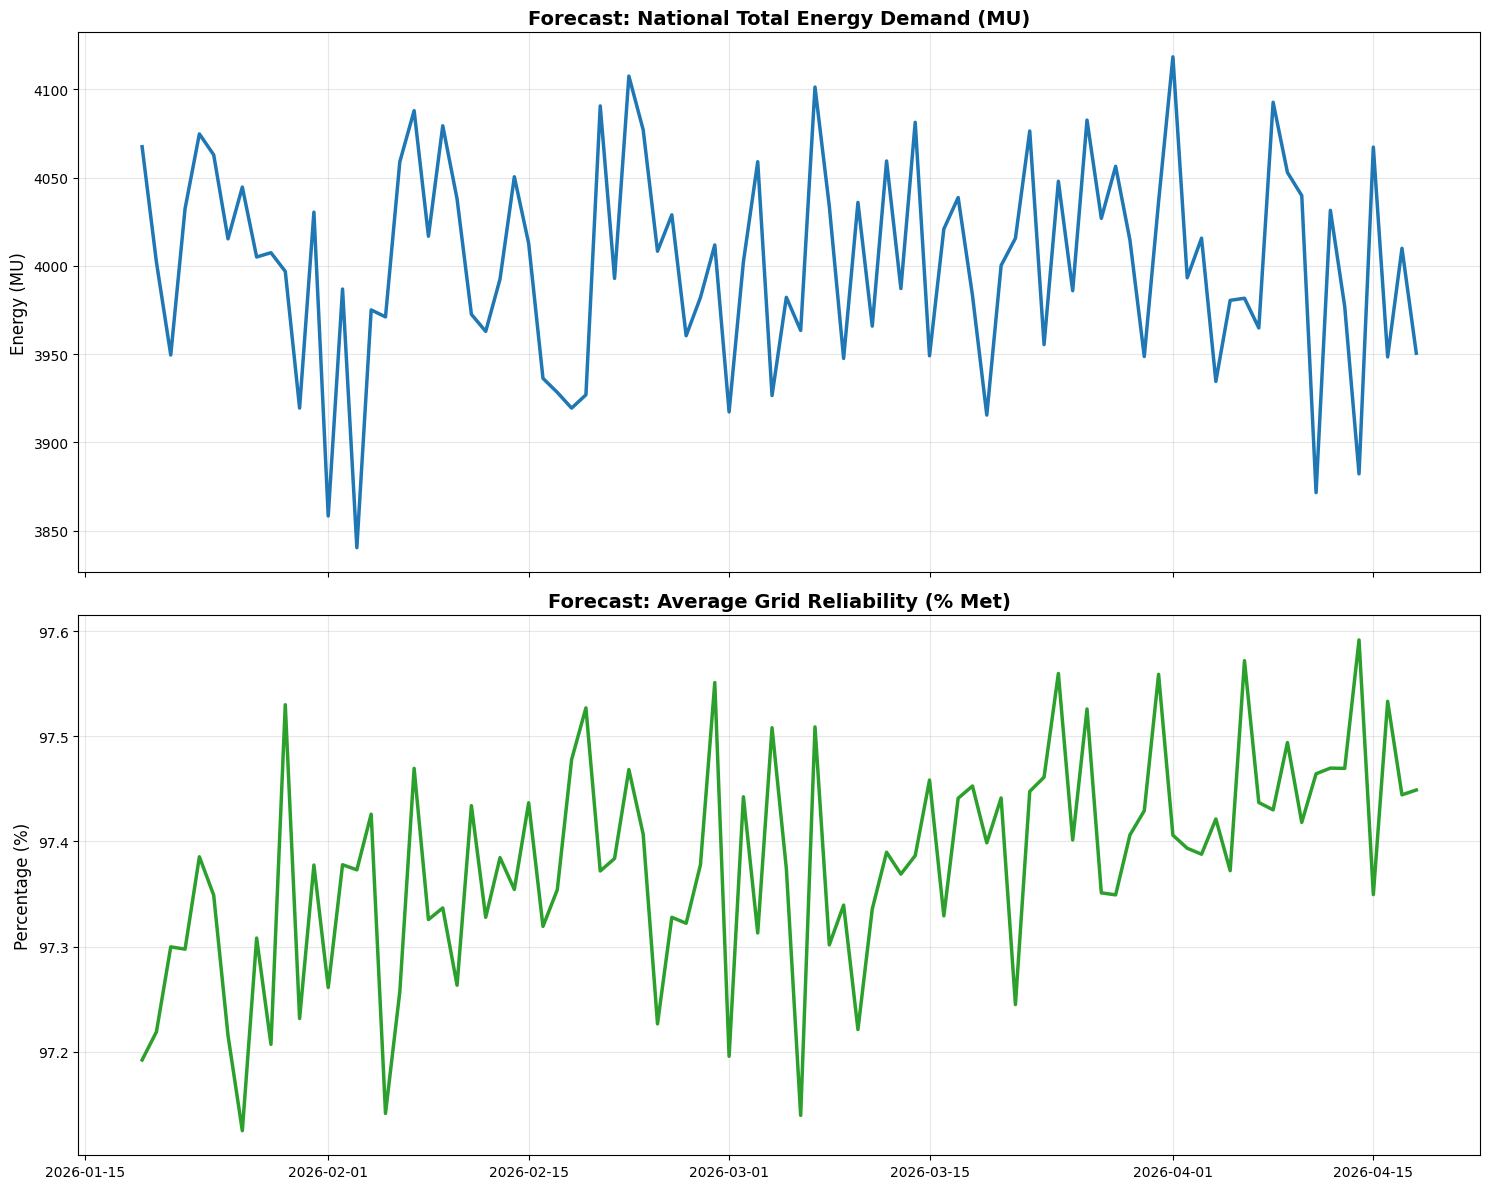

Plotting trends for Top 5 States: ['Maharashtra', 'Gujarat', 'UP', 'Tamil Nadu', 'Rajasthan']


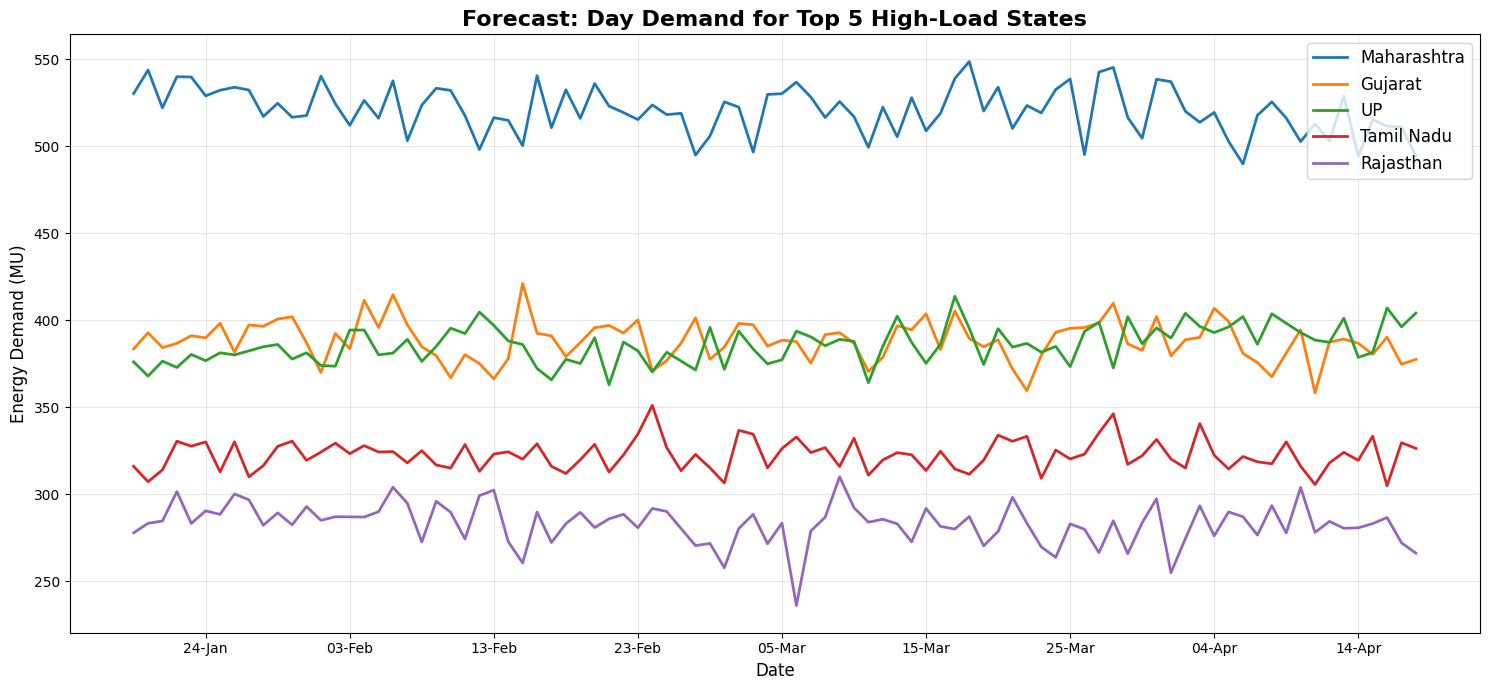

In [10]:
#graphs
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

CODES_DIR = Path(r"C:\Users\adrme\OneDrive\Music\Codes")
FORECAST_FILE = CODES_DIR / 'Forecast_Next_3_Months.xlsx'

def plot_forecast_results():
    print("--- Generatng Forecast Graphs ---")

    if not FORECAST_FILE.exists():
        print("Error: Forecast file not found.")
        return

    df = pd.read_excel(FORECAST_FILE)
    df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
    
    print(f"Plotting data from {df['Date'].min().date()} to {df['Date'].max().date()}")

    national_df = df.groupby('Date').agg({
        'Forecast_Day_Demand_MU': 'sum',
        'Forecast_Percentage_Met': 'mean',
    }).reset_index()

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12), sharex=True)
    
    ax1.plot(national_df['Date'], national_df['Forecast_Day_Demand_MU'], color='#1f77b4', linewidth=2.5)
    ax1.set_title('Forecast: National Total Energy Demand (MU)', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Energy (MU)', fontsize=12)
    ax1.grid(True, alpha=0.3)

    ax2.plot(national_df['Date'], national_df['Forecast_Percentage_Met'], color='#2ca02c', linewidth=2.5)
    ax2.set_title('Forecast: Average Grid Reliability (% Met)', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Percentage (%)', fontsize=12)
    ax2.grid(True, alpha=0.3)
        
    plt.tight_layout()
    plt.show()

    top_states = df.groupby('State')['Forecast_Day_Demand_MU'].sum().nlargest(5).index.tolist()
    
    print(f"Plotting trends for Top 5 States: {top_states}")

    plt.figure(figsize=(15, 7))
    
    for state in top_states:
        state_data = df[df['State'] == state]
        plt.plot(state_data['Date'], state_data['Forecast_Day_Demand_MU'], label=state, linewidth=2)
    
    plt.title('Forecast: Day Demand for Top 5 High-Load States', fontsize=16, fontweight='bold')
    plt.ylabel('Energy Demand (MU)', fontsize=12)
    plt.xlabel('Date', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
    plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=10))
    
    plt.tight_layout()
    plt.show()

plot_forecast_results()